# Тема 4. Линейные модели

## Практика: логистическая регрессия против дерева на «Титанике»

В теме 3 дерево решений на этих же признаках дало accuracy ≈0.80 на valid. Сегодня — линейная модель на той же задаче: совпадёт результат с деревом или разойдётся, как это было с оттоком (86.5% логрегрессия против 93-94% дерева)?

Самостоятельная работа. Если не хватает метода — см. `lesson04_linear_models_theory.ipynb`.

**Это файл с решениями — используйте для самопроверки.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

**1. Подготовка данных** — та же, что в теме 3 (чтобы результаты были честно сравнимы).

In [2]:
data = pd.read_csv("../data/titanic_train.csv", index_col="PassengerId")
data["Sex"] = (data["Sex"] == "male").astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features]
y = data["Survived"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

**2. Отмасштабируйте `X_train`/`X_valid` через `StandardScaler` (не забудьте: `fit_transform` на train, `transform` на valid), обучите `LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)`. Какая accuracy на valid?**

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

logreg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
logreg.fit(X_train_s, y_train)
round(logreg.score(X_valid_s, y_valid), 4)

0.8022

**3. Постройте коэффициенты в виде `barh`. У какого признака коэффициент по модулю самый большой? Совпадает ли знак с тем, что вы видели в теме 2 (countplot `Sex` × `Survived`)?**

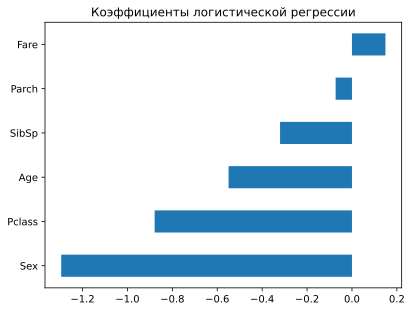

In [4]:
pd.Series(logreg.coef_[0], index=features).sort_values().plot(
    kind="barh", title="Коэффициенты логистической регрессии"
);

**4. Кривая валидации по `C`.** Переберите `C` из `np.logspace(-3, 2, 12)`, для каждого обучите модель на `X_train_s`, посчитайте accuracy на `X_valid_s`, постройте график (ось X — `C` в логарифмической шкале, ось Y — accuracy).

При каких `C` модель недообучена (регуляризация слишком сильная)?

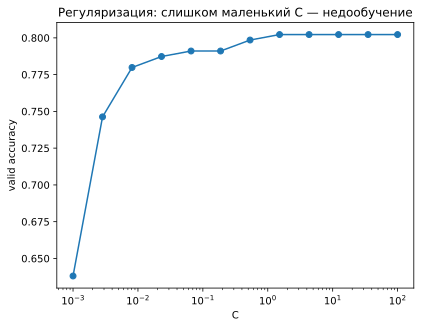

In [5]:
Cs = np.logspace(-3, 2, 12)
scores = []
for C in Cs:
    lr = LogisticRegression(C=C, random_state=RANDOM_STATE, max_iter=1000)
    lr.fit(X_train_s, y_train)
    scores.append(lr.score(X_valid_s, y_valid))

plt.plot(Cs, scores, marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("valid accuracy")
plt.title("Регуляризация: слишком маленький C — недообучение");

**5. Сравните лучшую accuracy логистической регрессии с деревом из практики темы 3 (≈0.80). Какая модель лучше на этой задаче? А на оттоке в теории — какая была лучше там? Одна фраза с выводом.**

_Пример вывода: на Titanic логрегрессия и дерево дают практически одинаковую accuracy (~0.80) — значит, зависимость здесь ближе к линейно-аддитивной. На оттоке дерево было заметно лучше (93-94% против 86.5%) — там явно есть пороговые/нелинейные эффекты (например, резкий скачок оттока после 4 обращений в поддержку), которые линейная модель в принципе не может выразить одной гиперплоскостью._

**6 (бонус). Обучите `LogisticRegression` без `Fare` (уберите её из списка признаков). Изменилась ли accuracy? А коэффициент `Pclass`?**

In [6]:
features_no_fare = ["Pclass", "Sex", "Age", "SibSp", "Parch"]
X_nf = data[features_no_fare]
X_train_nf, X_valid_nf, _, _ = train_test_split(
    X_nf, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train_nf_s = scaler.fit_transform(X_train_nf)
X_valid_nf_s = scaler.transform(X_valid_nf)

lr_nf = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000).fit(X_train_nf_s, y_train)
print("accuracy:", round(lr_nf.score(X_valid_nf_s, y_valid), 4))
print("коэфф. Pclass:", round(pd.Series(lr_nf.coef_[0], index=features_no_fare)["Pclass"], 3))

accuracy: 0.7873
коэфф. Pclass: -0.955


---
## Итог

Два принципиально разных подхода (дерево и линейная модель) дают на одной задаче разный результат в зависимости от формы зависимости в данных. Следующее занятие — ансамблевые методы: что будет, если объединить много деревьев вместе.